In [16]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose


In [17]:
df = pd.read_csv('../data/raw/ec2_cpu_utilization_24ae8d.csv', parse_dates=['timestamp'])
df = df.set_index('timestamp')

tamanho_treino = int(len(df) * 0.8)
treino = df.iloc[:tamanho_treino].copy()

In [18]:
m = 288
print(f'Periodo sazonal: {m} pontos = 1 dia')

Periodo sazonal: 288 pontos = 1 dia


In [19]:
pesos = np.array([0.5] + [1] * (m - 1) + [0.5]) / m

valores = treino['value'].values
tendencia_valores = np.convolve(valores, pesos, mode='valid')

offset = m // 2
tendencia = pd.Series(np.nan, index=treino.index)
tendencia.iloc[offset: offset + len(tendencia_valores)] = tendencia_valores

In [20]:
sem_tendencia = treino['value'] - tendencia

In [21]:
posicao_no_ciclo = np.arange(len(treino)) % m

perfil_sazonal = pd.Series(sem_tendencia.values, index=posicao_no_ciclo).groupby(level=0).mean()

perfil_sazonal = perfil_sazonal - perfil_sazonal.mean()

sazonalidade = pd.Series(
    np.tile(perfil_sazonal.values, len(treino) // m + 1)[:len(treino)],
    index=treino.index
)

In [22]:
residuo = treino['value'] - tendencia - sazonalidade

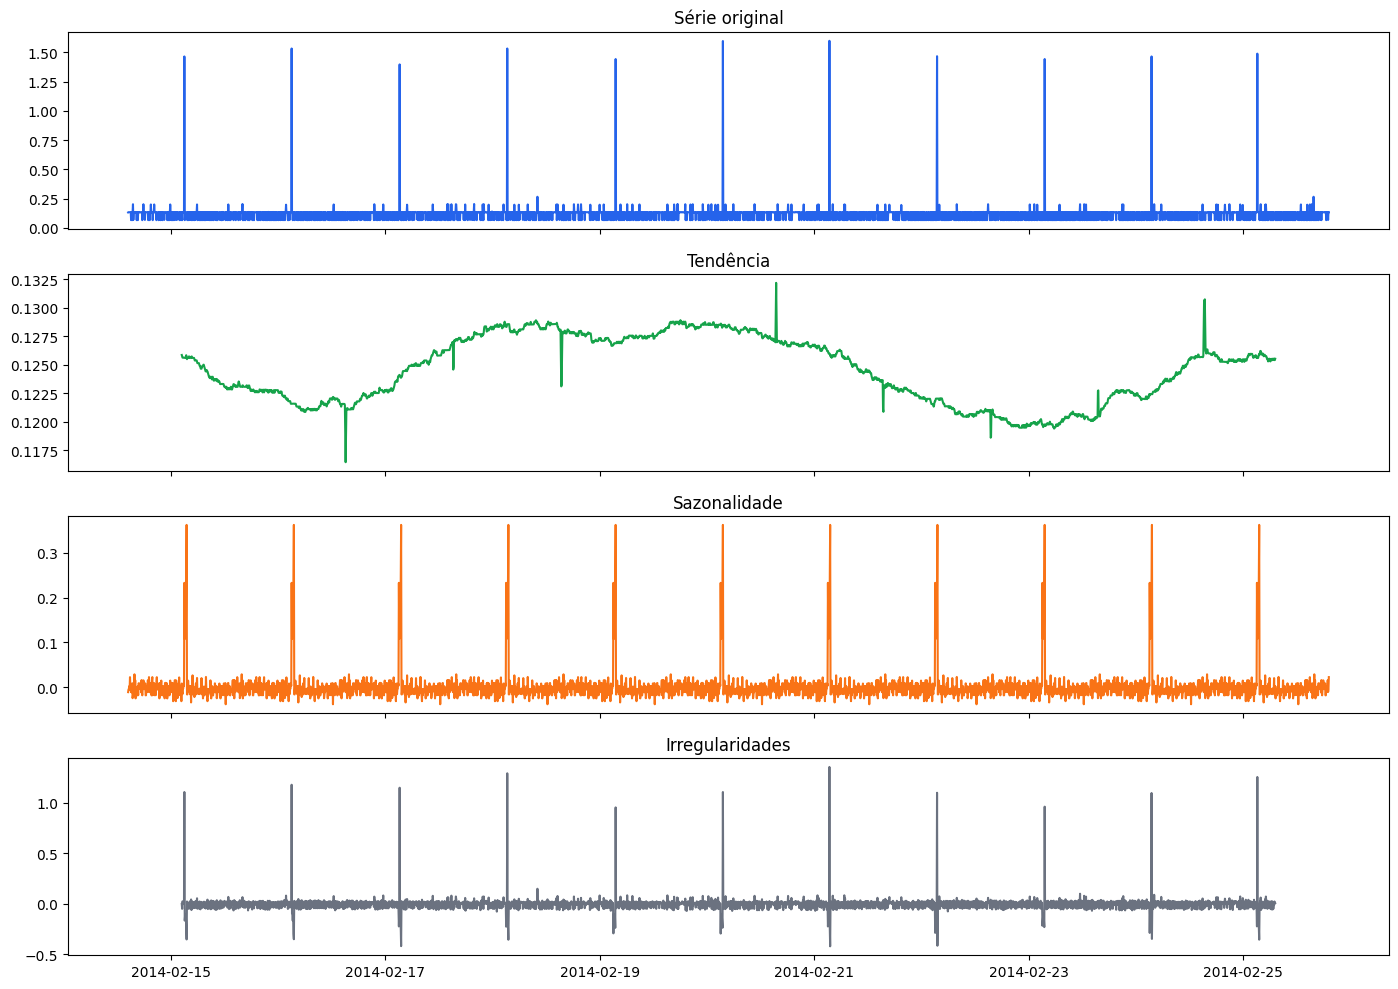

In [23]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(treino.index, treino['value'], color='#2563eb')
axes[0].set_title('Série original')

axes[1].plot(treino.index, tendencia, color='#16a34a')
axes[1].set_title('Tendência')

axes[2].plot(treino.index, sazonalidade, color='#f97316')
axes[2].set_title('Sazonalidade')

axes[3].plot(treino.index, residuo, color='#6b7280')
axes[3].set_title('Irregularidades')

plt.tight_layout()
plt.show()

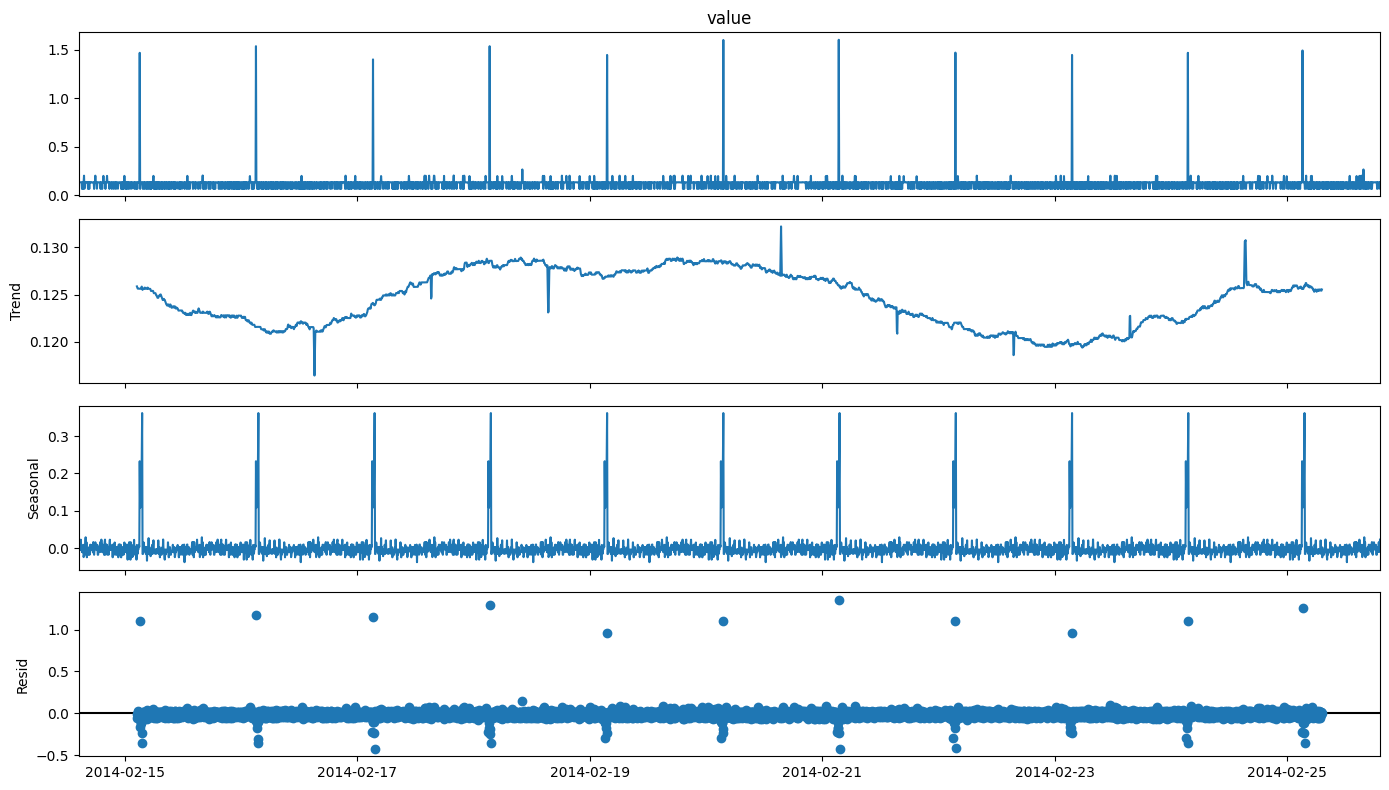

In [24]:
resultado_lib = seasonal_decompose(treino['value'], model='additive', period=m)

fig = resultado_lib.plot()
fig.set_size_inches(14, 8)
plt.tight_layout()
plt.show()

In [25]:
comparacao = pd.DataFrame({
    'tendencia_manual': tendencia,
    'tendencia_statsmodels': resultado_lib.trend,
    'sazonalidade_manual': sazonalidade,
    'sazonalidade_statsmodels': resultado_lib.seasonal,
})

diff_tendencia = (comparacao['tendencia_manual'] - comparacao['tendencia_statsmodels']).abs().mean()
diff_sazonalidade = (comparacao['sazonalidade_manual'] - comparacao['sazonalidade_statsmodels']).abs().mean()

print(f'Diferença média absoluta - tendência:    {diff_tendencia:.6f}')
print(f'Diferença média absoluta - sazonalidade: {diff_sazonalidade:.6f}')

Diferença média absoluta - tendência:    0.000000
Diferença média absoluta - sazonalidade: 0.000000


In [26]:
df = pd.read_csv('../data/raw/ec2_cpu_utilization_24ae8d.csv', parse_dates=['timestamp'])
df = df.set_index('timestamp')

m = 288  # período sazonal: 1 dia = 288 pontos de 5 minutos

tamanho_treino = int(len(df) * 0.8)
treino = df.iloc[:tamanho_treino].copy()
teste = df.iloc[tamanho_treino:].copy()

In [27]:
posicao_treino = np.arange(len(treino)) % m
perfil_sazonal = pd.Series(treino['value'].values, index=posicao_treino).groupby(level=0).mean()

In [28]:
posicao_global_teste = np.arange(tamanho_treino, tamanho_treino + len(teste)) % m
esperado_teste = perfil_sazonal.reindex(posicao_global_teste).values

residuo_teste = pd.Series(teste['value'].values - esperado_teste, index=teste.index)

In [29]:
with open('../data/labels/combined_windows.json') as f:
    labels = json.load(f)

windows = labels['realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv']
windows = [(pd.Timestamp(w[0]), pd.Timestamp(w[1])) for w in windows]

dentro_anomalia = pd.Series(False, index=teste.index)
for start, end in windows:
    dentro_anomalia |= (teste.index >= start) & (teste.index <= end)

residuo_normal = residuo_teste[~dentro_anomalia]
residuo_anomalo = residuo_teste[dentro_anomalia]

In [33]:
comparacao = pd.DataFrame({
    'fora da janela': residuo_normal.abs().describe(),
    'dentro da janela': residuo_anomalo.abs().describe(),
})
comparacao

,fora da janela,dentro da janela
count,405.000000,402.000000
mean,0.037692,0.038601
std,0.098988,0.135990
min,0.000182,0.000000
25%,0.012364,0.009542
50%,0.020000,0.018727
75%,0.041273,0.037045
max,1.363091,2.216364


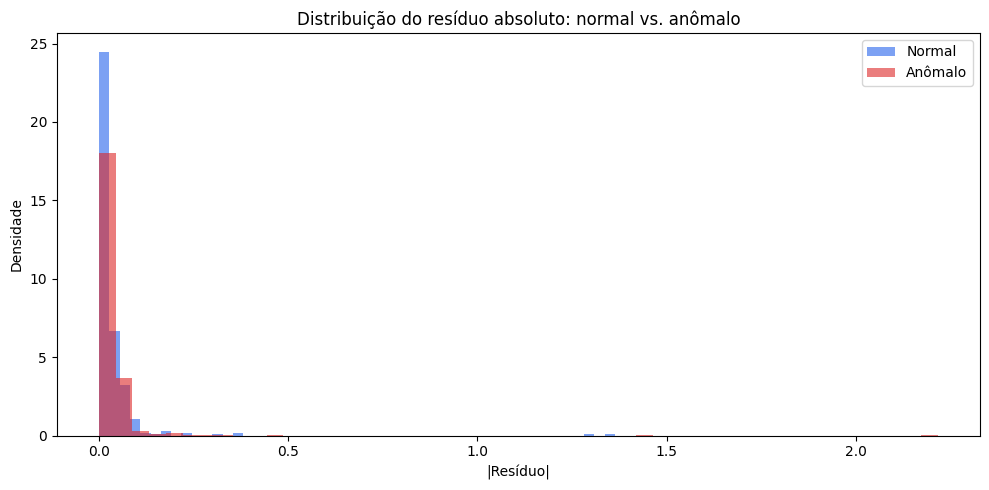

In [31]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(residuo_normal.abs(), bins=50, alpha=0.6, label='Normal', color='#2563eb', density=True)
ax.hist(residuo_anomalo.abs(), bins=50, alpha=0.6, label='Anômalo', color='#dc2626', density=True)
ax.set_xlabel('|Resíduo|')
ax.set_ylabel('Densidade')
ax.set_title('Distribuição do resíduo absoluto: normal vs. anômalo')
ax.legend()
plt.tight_layout()
plt.show()

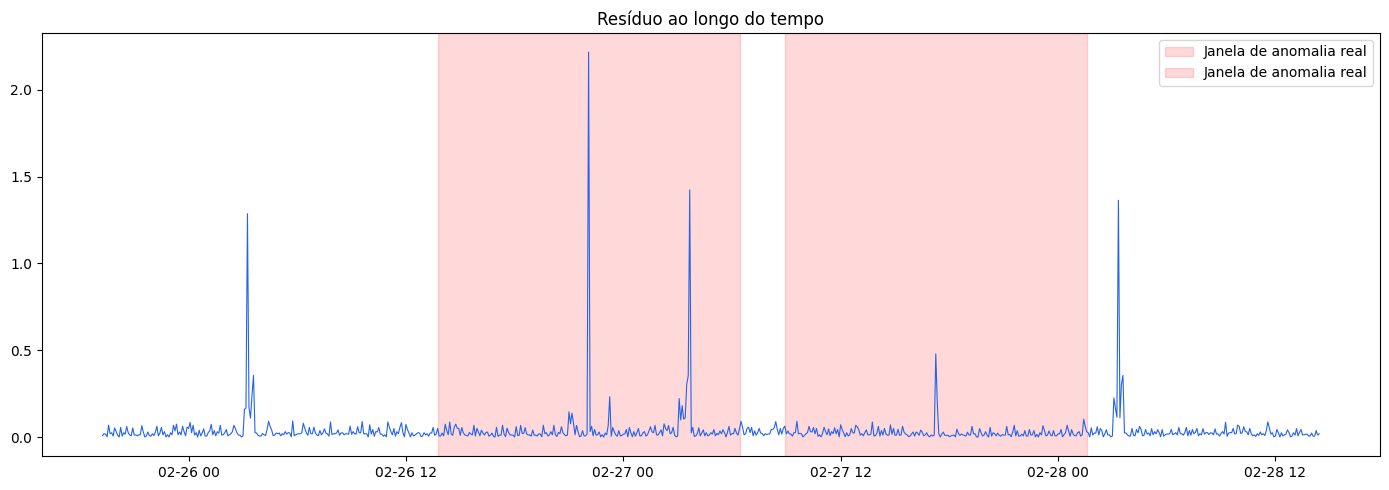

: 

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(residuo_teste.index, residuo_teste.abs(), linewidth=0.8, color='#2563eb')
for start, end in windows:
    ax.axvspan(start, end, color='red', alpha=0.15, label='Janela de anomalia real')
ax.set_title('Resíduo ao longo do tempo')
ax.legend()
plt.tight_layout()
plt.show()